## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [2]:
import blue_sampler as blue
import numpy as np

In [15]:
def centroids(x):
    """
    x is a batch of quadrilaters of the shape (batch, 4, 2)
    we just compute barycenter for each tesselsrilateral
    """
    return x.mean(axis = 1)

def solve_moment(x, p):
    """
    one can also sample hyperuniform points by solving a moment equation,
    solving moment equality to all orders between 0 and p-1
    to strenghten hyperunformity. This is done by blue.from_geometry wich internaly
    solve the moment equation
    """
    return blue.from_geometry(x, gtype = "polygons", p = p)


## fair STIT allow to sample 1 million tessels in a matter of seconds
Here we show only the first tesselation steps

In [ ]:
tessels = blue.sample_tessels(N = 2**16)

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

(65536, 2)


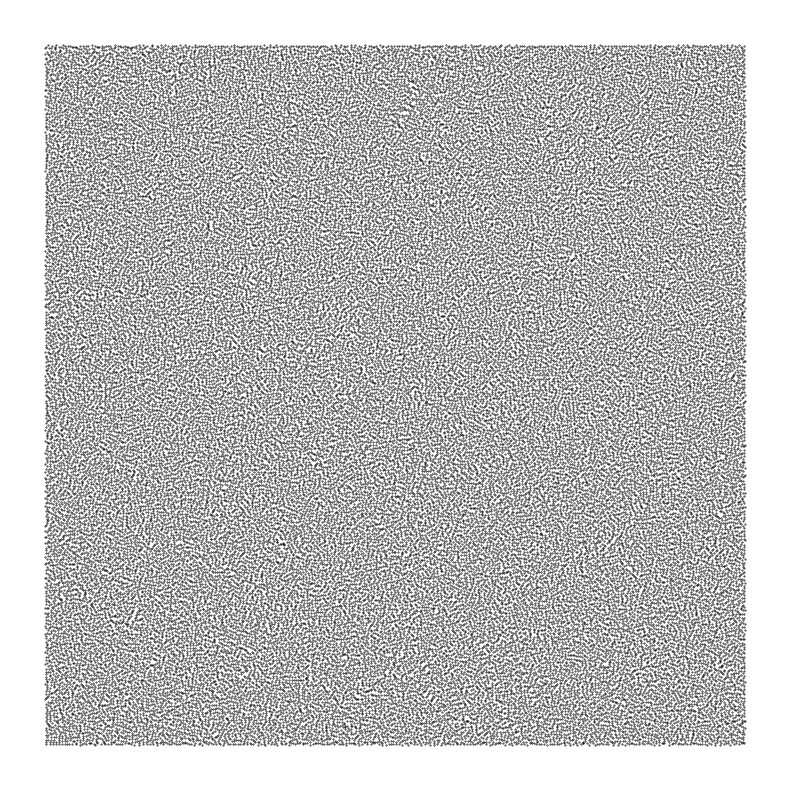

In [ ]:
x_center = tessels.mean(axis = 1)
print(x_center.shape)
blue.plot(x_center)

But one can also solve moment equation, eg solve moment up to order 2 (p = 3). slower but better results

(196608, 2)


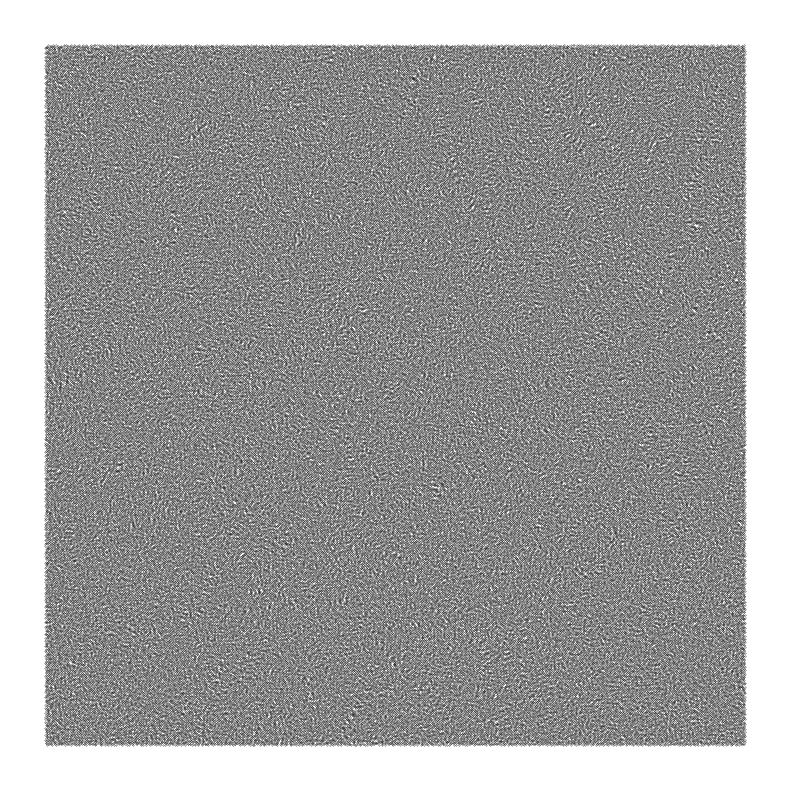

In [ ]:
x_moment2 = solve_moment(tessels, p = 3).reshape(-1, 2)
print(x_moment2.shape)
blue.plot(x_moment2)

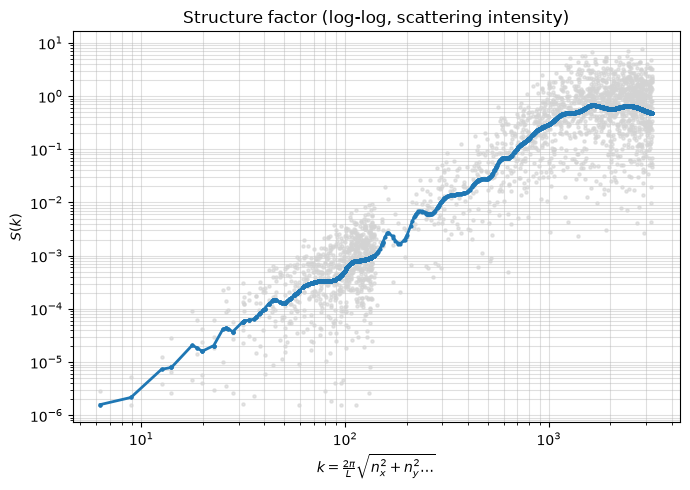

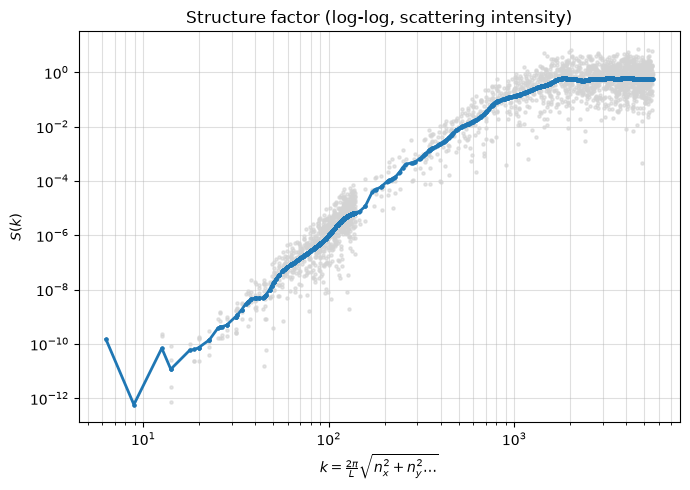

In [10]:
blue.plot_structure_factor(x_center)
blue.plot_structure_factor(x_moment2) #slower but better

## Tessels for adaptative sampling

In [11]:
from blue_sampler.datasets import generate_dataset

In [19]:
N = 1024*32
K = N * 100
targets = generate_dataset(dataset = "barbara", size = (K, 2), plot_data = False)
tessels, atoms = blue.sample_tessels(N =N, targets = targets, return_atoms = True)

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


## Here comes the magic

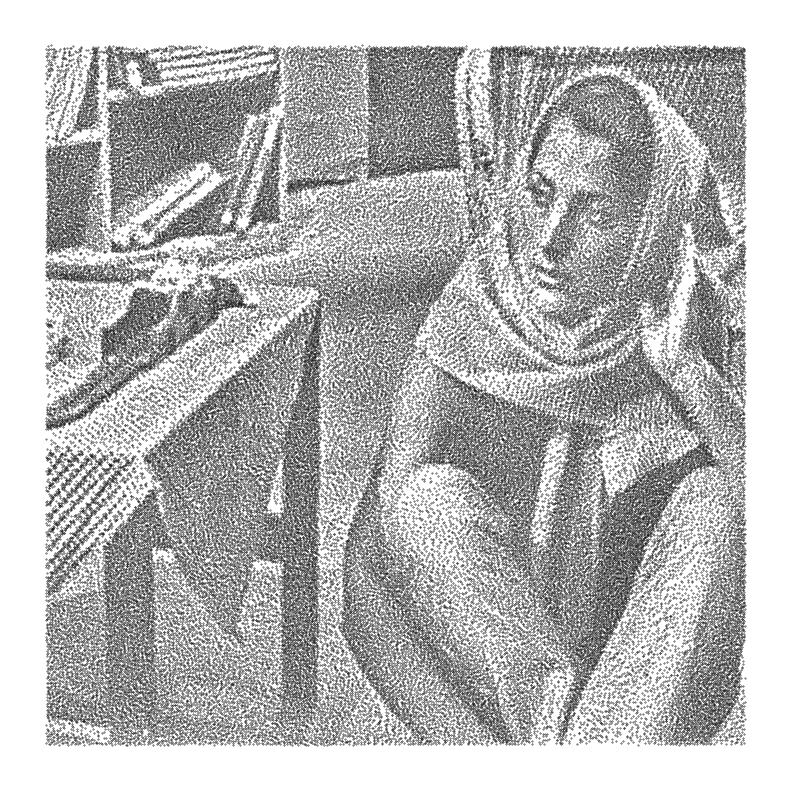

In [20]:
x = blue.from_geometry(atoms, gtype = "clusters", p = 3).reshape(-1, 2)
_ = blue.plot(x)